# 06 Evaluate Improved WLASL100 Model

This notebook evaluates the improved WLASL100 model trained in `05_train_improved_wlasl100_bigru_attention.ipynb`.

The goal is to understand the model beyond overall accuracy by checking:

- Test Top-1, Top-3, and Top-5 accuracy
- Macro F1-score
- Per-class accuracy
- Per-class Top-5 success
- Best-performing signs
- Worst-performing signs
- Most common class confusions
- High-confidence wrong predictions
- Examples where Top-1 is wrong but Top-5 is correct

This helps decide what to improve before moving to WLASL300.

In [1]:
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore", category=UserWarning)

e:\Be_My_Ear\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path("E:/Be_My_Ear")

BASE_DIR = PROJECT_ROOT / "data" / "processed" / "ASL" / "WLASL100"
CLEAN_INDEX_FILE = BASE_DIR / "wlasl100_clean_keypoint_index.csv"
LABEL_MAP_FILE = PROJECT_ROOT / "data" / "label_maps" / "asl_wlasl100_labels.json"

MODEL_DIR = PROJECT_ROOT / "models" / "ASL"
MODEL_PATH = MODEL_DIR / "improved_bigru_attention_wlasl100.pt"
NORM_STATS_PATH = MODEL_DIR / "wlasl100_train_norm_stats.npz"

EVAL_DIR = PROJECT_ROOT / "reports" / "phase1_wlasl100"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print("Clean index exists:", CLEAN_INDEX_FILE.exists())
print("Label map exists:", LABEL_MAP_FILE.exists())
print("Model checkpoint exists:", MODEL_PATH.exists())
print("Normalisation stats exists:", NORM_STATS_PATH.exists())
print("Evaluation reports will save to:", EVAL_DIR)

Clean index exists: True
Label map exists: True
Model checkpoint exists: True
Normalisation stats exists: True
Evaluation reports will save to: E:\Be_My_Ear\reports\phase1_wlasl100


## 1. Load dataset and label map

In [3]:
df = pd.read_csv(CLEAN_INDEX_FILE)

with open(LABEL_MAP_FILE, "r", encoding="utf-8") as f:
    label_map = json.load(f)

id_to_gloss = {
    int(label_id): info["gloss"]
    for label_id, info in label_map.items()
}

NUM_CLASSES = df["label_id"].nunique()

print("Clean samples:", len(df))
print("Classes:", NUM_CLASSES)
print("First label examples:")
list(id_to_gloss.items())[:10]

Clean samples: 1013
Classes: 100
First label examples:


[(0, 'accident'),
 (1, 'africa'),
 (2, 'all'),
 (3, 'apple'),
 (4, 'basketball'),
 (5, 'bed'),
 (6, 'before'),
 (7, 'bird'),
 (8, 'birthday'),
 (9, 'black')]

## 2. Recreate the same train / validation / test split

The evaluation notebook recreates the same split logic used in the improved training notebook so the test set is consistent.

In [4]:
train_records = []
val_records = []
test_records = []

for label_id, group in df.groupby("label_id"):
    group = group.sample(frac=1, random_state=SEED).reset_index(drop=True)

    n = len(group)

    n_test = max(1, int(round(n * 0.15)))
    n_val = max(1, int(round(n * 0.15)))

    test_part = group.iloc[:n_test]
    val_part = group.iloc[n_test:n_test + n_val]
    train_part = group.iloc[n_test + n_val:]

    train_records.append(train_part)
    val_records.append(val_part)
    test_records.append(test_part)

train_df = pd.concat(train_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_records).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_records).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("Train classes:", train_df["label_id"].nunique())
print("Validation classes:", val_df["label_id"].nunique())
print("Test classes:", test_df["label_id"].nunique())

Train samples: 697
Validation samples: 158
Test samples: 158
Train classes: 100
Validation classes: 100
Test classes: 100


## 3. Load normalisation statistics

The improved model uses global training-set normalisation. If the saved normalisation file is missing, this notebook recomputes it from the training split.

In [5]:
def compute_train_normalisation_stats(train_dataframe):
    total_sum = None
    total_sq_sum = None
    total_count = 0

    for path in tqdm(train_dataframe["keypoint_path"], desc="Computing train mean/std"):
        arr = np.load(path).astype(np.float32)

        if total_sum is None:
            total_sum = arr.sum(axis=0)
            total_sq_sum = (arr ** 2).sum(axis=0)
        else:
            total_sum += arr.sum(axis=0)
            total_sq_sum += (arr ** 2).sum(axis=0)

        total_count += arr.shape[0]

    mean = total_sum / total_count
    variance = (total_sq_sum / total_count) - (mean ** 2)
    variance = np.maximum(variance, 1e-6)
    std = np.sqrt(variance)

    return mean.astype(np.float32), std.astype(np.float32)


if NORM_STATS_PATH.exists():
    norm_stats = np.load(NORM_STATS_PATH)
    train_mean = norm_stats["mean"].astype(np.float32)
    train_std = norm_stats["std"].astype(np.float32)
    print("Loaded normalisation stats from:", NORM_STATS_PATH)
else:
    train_mean, train_std = compute_train_normalisation_stats(train_df)
    np.savez(NORM_STATS_PATH, mean=train_mean, std=train_std)
    print("Recomputed and saved normalisation stats to:", NORM_STATS_PATH)

print("Mean shape:", train_mean.shape)
print("Std shape:", train_std.shape)

Loaded normalisation stats from: E:\Be_My_Ear\models\ASL\wlasl100_train_norm_stats.npz
Mean shape: (258,)
Std shape: (258,)


## 4. Dataset class

This must match the improved model training notebook. It uses normalised keypoints plus velocity features.

In [6]:
class ImprovedSignKeypointDataset(Dataset):
    def __init__(self, dataframe, mean, std, use_velocity=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.mean = mean.reshape(1, -1).astype(np.float32)
        self.std = std.reshape(1, -1).astype(np.float32)
        self.use_velocity = use_velocity

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        keypoints = np.load(row["keypoint_path"]).astype(np.float32)

        keypoints = (keypoints - self.mean) / (self.std + 1e-6)

        if self.use_velocity:
            velocity = np.zeros_like(keypoints, dtype=np.float32)
            velocity[1:] = keypoints[1:] - keypoints[:-1]
            features = np.concatenate([keypoints, velocity], axis=1)
        else:
            features = keypoints

        label = int(row["label_id"])

        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return features, label

In [7]:
BATCH_SIZE = 32
USE_VELOCITY = True
INPUT_SIZE = 516 if USE_VELOCITY else 258

train_dataset = ImprovedSignKeypointDataset(train_df, train_mean, train_std, use_velocity=USE_VELOCITY)
val_dataset = ImprovedSignKeypointDataset(val_df, train_mean, train_std, use_velocity=USE_VELOCITY)
test_dataset = ImprovedSignKeypointDataset(test_df, train_mean, train_std, use_velocity=USE_VELOCITY)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x_batch, y_batch = next(iter(test_loader))

print("Test input batch shape:", x_batch.shape)
print("Test label batch shape:", y_batch.shape)

Test input batch shape: torch.Size([32, 60, 516])
Test label batch shape: torch.Size([32])


## 5. Recreate model architecture and load checkpoint

The class definition must match the model used in `05_train_improved_wlasl100_bigru_attention.ipynb`.

In [8]:
class BiGRUAttentionModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_classes,
        num_layers=2,
        dropout=0.4
    ):
        super(BiGRUAttentionModel, self).__init__()

        self.input_projection = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        x = self.input_projection(x)

        gru_out, _ = self.gru(x)

        attention_scores = self.attention(gru_out).squeeze(-1)
        attention_weights = torch.softmax(attention_scores, dim=1).unsqueeze(-1)

        context = torch.sum(gru_out * attention_weights, dim=1)

        logits = self.classifier(context)

        return logits

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

checkpoint = torch.load(MODEL_PATH, map_location=device)

model = BiGRUAttentionModel(
    input_size=checkpoint.get("input_size", INPUT_SIZE),
    hidden_size=256,
    num_classes=checkpoint.get("num_classes", NUM_CLASSES),
    num_layers=2,
    dropout=0.4
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint from:", MODEL_PATH)
print("Best checkpoint epoch:", checkpoint.get("epoch"))
print("Best validation F1:", checkpoint.get("best_val_f1"))
print("Best validation Top-5:", checkpoint.get("best_val_top5"))

Using device: cpu
Loaded checkpoint from: E:\Be_My_Ear\models\ASL\improved_bigru_attention_wlasl100.pt
Best checkpoint epoch: 45
Best validation F1: 0.47233333333333327
Best validation Top-5: 0.8220833301544189


## 6. Collect predictions

In [10]:
def collect_predictions(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Collecting predictions"):
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)

print("Predictions collected:", len(y_pred))

Predictions collected: 158


## 7. Overall metrics

In [11]:
def numpy_top_k_accuracy(y_true, y_probs, k):
    correct = 0

    for true_label, prob in zip(y_true, y_probs):
        top_k_preds = np.argsort(prob)[-k:]
        if true_label in top_k_preds:
            correct += 1

    return correct / len(y_true)


test_top1 = accuracy_score(y_true, y_pred)
test_top3 = numpy_top_k_accuracy(y_true, y_probs, k=3)
test_top5 = numpy_top_k_accuracy(y_true, y_probs, k=5)
test_macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=" * 80)
print("Improved WLASL100 Model Evaluation")
print("=" * 80)
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print("=" * 80)

Improved WLASL100 Model Evaluation
Test Top-1 Accuracy: 0.4304
Test Top-3 Accuracy: 0.7089
Test Top-5 Accuracy: 0.7911
Test Macro F1: 0.3855


In [12]:
overall_metrics = pd.DataFrame([{
    "dataset": "WLASL100",
    "model": "BiGRU + Temporal Attention",
    "clean_samples": len(df),
    "classes": NUM_CLASSES,
    "test_samples": len(test_df),
    "test_top1_accuracy": test_top1,
    "test_top3_accuracy": test_top3,
    "test_top5_accuracy": test_top5,
    "test_macro_f1": test_macro_f1,
    "best_val_f1": checkpoint.get("best_val_f1"),
    "best_val_top5": checkpoint.get("best_val_top5"),
    "checkpoint_epoch": checkpoint.get("epoch")
}])

OVERALL_METRICS_FILE = EVAL_DIR / "improved_wlasl100_overall_metrics.csv"
overall_metrics.to_csv(OVERALL_METRICS_FILE, index=False)

print("Saved overall metrics to:")
print(OVERALL_METRICS_FILE)

overall_metrics

Saved overall metrics to:
E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_overall_metrics.csv


,dataset,model,clean_samples,classes,test_samples,test_top1_accuracy,test_top3_accuracy,test_top5_accuracy,test_macro_f1,best_val_f1,best_val_top5,checkpoint_epoch
0,WLASL100,BiGRU + Temporal Attention,1013,100,158,0.43038,0.708861,0.791139,0.385524,0.472333,0.822083,45


## 8. Per-class performance

This shows which signs the model recognises well and which signs need improvement.

In [13]:
per_class_records = []

for label_id in sorted(np.unique(y_true)):
    mask = y_true == label_id

    class_true = y_true[mask]
    class_pred = y_pred[mask]
    class_probs = y_probs[mask]

    top1_acc = accuracy_score(class_true, class_pred)
    top3_acc = numpy_top_k_accuracy(class_true, class_probs, k=3)
    top5_acc = numpy_top_k_accuracy(class_true, class_probs, k=5)

    per_class_records.append({
        "label_id": int(label_id),
        "gloss": id_to_gloss.get(int(label_id), str(label_id)),
        "test_samples": int(mask.sum()),
        "top1_accuracy": top1_acc,
        "top3_accuracy": top3_acc,
        "top5_accuracy": top5_acc
    })

per_class_df = pd.DataFrame(per_class_records)

PER_CLASS_FILE = EVAL_DIR / "improved_wlasl100_per_class_performance.csv"
per_class_df.to_csv(PER_CLASS_FILE, index=False)

print("Saved per-class performance to:")
print(PER_CLASS_FILE)

per_class_df.head()

Saved per-class performance to:
E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_per_class_performance.csv


,label_id,gloss,test_samples,top1_accuracy,top3_accuracy,top5_accuracy
0,0,accident,2,0.0,0.5,0.5
1,1,africa,1,0.0,1.0,1.0
2,2,all,1,0.0,0.0,0.0
3,3,apple,2,0.5,0.5,1.0
4,4,basketball,2,0.0,0.5,0.5


In [14]:
print("Best-performing classes by Top-1 accuracy:")
per_class_df.sort_values(
    ["top1_accuracy", "top5_accuracy", "test_samples"],
    ascending=[False, False, False]
).head(15)

Best-performing classes by Top-1 accuracy:


,label_id,gloss,test_samples,top1_accuracy,top3_accuracy,top5_accuracy
7,7,bird,2,1.0,1.0,1.0
18,18,change,2,1.0,1.0,1.0
27,27,cousin,2,1.0,1.0,1.0
30,30,dark,2,1.0,1.0,1.0
31,31,deaf,2,1.0,1.0,1.0
35,35,drink,2,1.0,1.0,1.0
38,38,family,2,1.0,1.0,1.0
43,43,full,2,1.0,1.0,1.0
45,45,go,2,1.0,1.0,1.0
56,56,later,2,1.0,1.0,1.0


In [15]:
print("Worst-performing classes by Top-1 accuracy:")
per_class_df.sort_values(
    ["top1_accuracy", "top5_accuracy", "test_samples"],
    ascending=[True, True, False]
).head(15)

Worst-performing classes by Top-1 accuracy:


,label_id,gloss,test_samples,top1_accuracy,top3_accuracy,top5_accuracy
26,26,corn,2,0.0,0.0,0.0
34,34,dog,2,0.0,0.0,0.0
87,87,thin,2,0.0,0.0,0.0
99,99,yes,2,0.0,0.0,0.0
2,2,all,1,0.0,0.0,0.0
39,39,fine,1,0.0,0.0,0.0
42,42,forget,1,0.0,0.0,0.0
47,47,hat,1,0.0,0.0,0.0
68,68,paint,1,0.0,0.0,0.0
73,73,pull,1,0.0,0.0,0.0


In [16]:
print("Classes where Top-1 is weak but Top-5 is strong:")
per_class_df["top5_minus_top1"] = per_class_df["top5_accuracy"] - per_class_df["top1_accuracy"]

per_class_df.sort_values(
    "top5_minus_top1",
    ascending=False
).head(15)

Classes where Top-1 is weak but Top-5 is strong:


,label_id,gloss,test_samples,top1_accuracy,top3_accuracy,top5_accuracy,top5_minus_top1
1,1,africa,1,0.0,1.0,1.0,1.0
17,17,chair,1,0.0,1.0,1.0,1.0
14,14,but,1,0.0,1.0,1.0,1.0
11,11,book,1,0.0,0.0,1.0,1.0
28,28,cow,1,0.0,1.0,1.0,1.0
22,22,color,1,0.0,1.0,1.0,1.0
21,21,clothes,1,0.0,1.0,1.0,1.0
20,20,city,1,0.0,1.0,1.0,1.0
86,86,thanksgiving,2,0.0,1.0,1.0,1.0
76,76,same,1,0.0,0.0,1.0,1.0


## 9. Visualise per-class accuracy

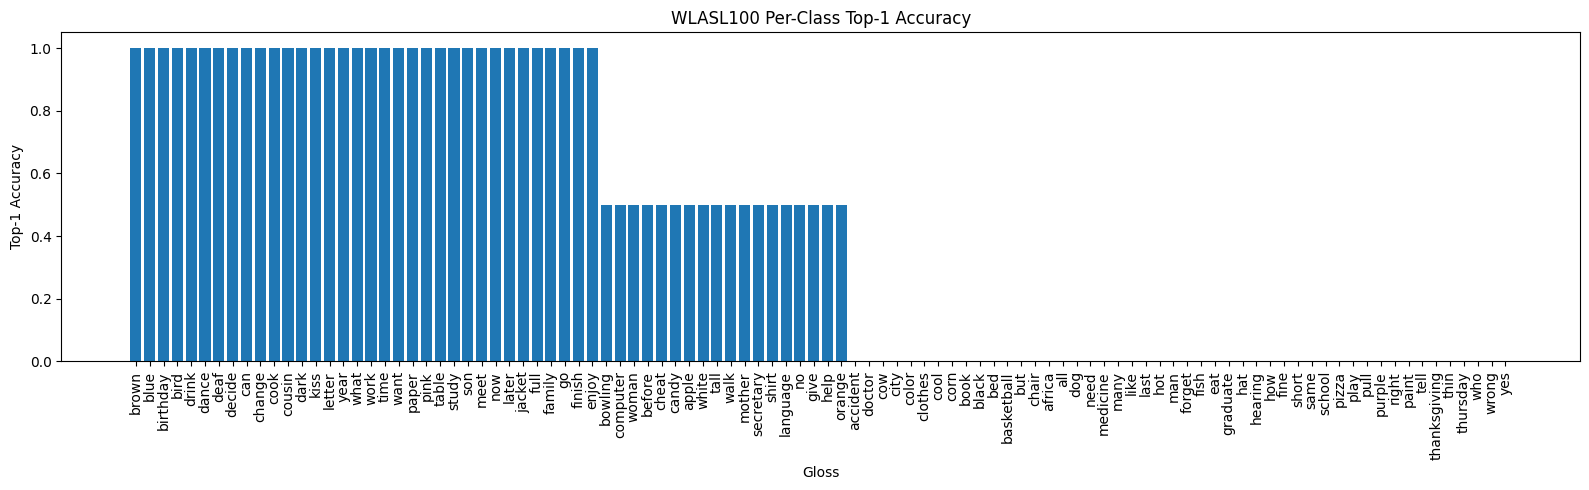

In [17]:
sorted_per_class = per_class_df.sort_values("top1_accuracy", ascending=False)

plt.figure(figsize=(16, 5))
plt.bar(sorted_per_class["gloss"], sorted_per_class["top1_accuracy"])
plt.title("WLASL100 Per-Class Top-1 Accuracy")
plt.xlabel("Gloss")
plt.ylabel("Top-1 Accuracy")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

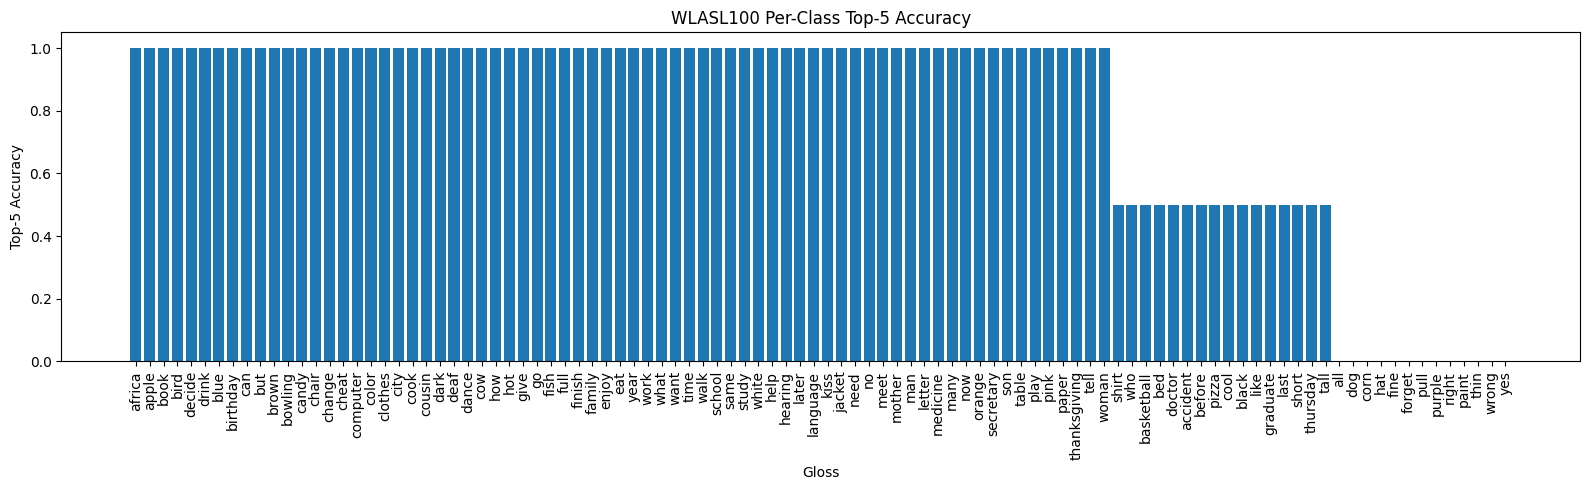

In [18]:
sorted_per_class = per_class_df.sort_values("top5_accuracy", ascending=False)

plt.figure(figsize=(16, 5))
plt.bar(sorted_per_class["gloss"], sorted_per_class["top5_accuracy"])
plt.title("WLASL100 Per-Class Top-5 Accuracy")
plt.xlabel("Gloss")
plt.ylabel("Top-5 Accuracy")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 10. Confusion matrix and common confusions

A full 100-class confusion matrix is hard to read, so this section also extracts the most common wrong pairs.

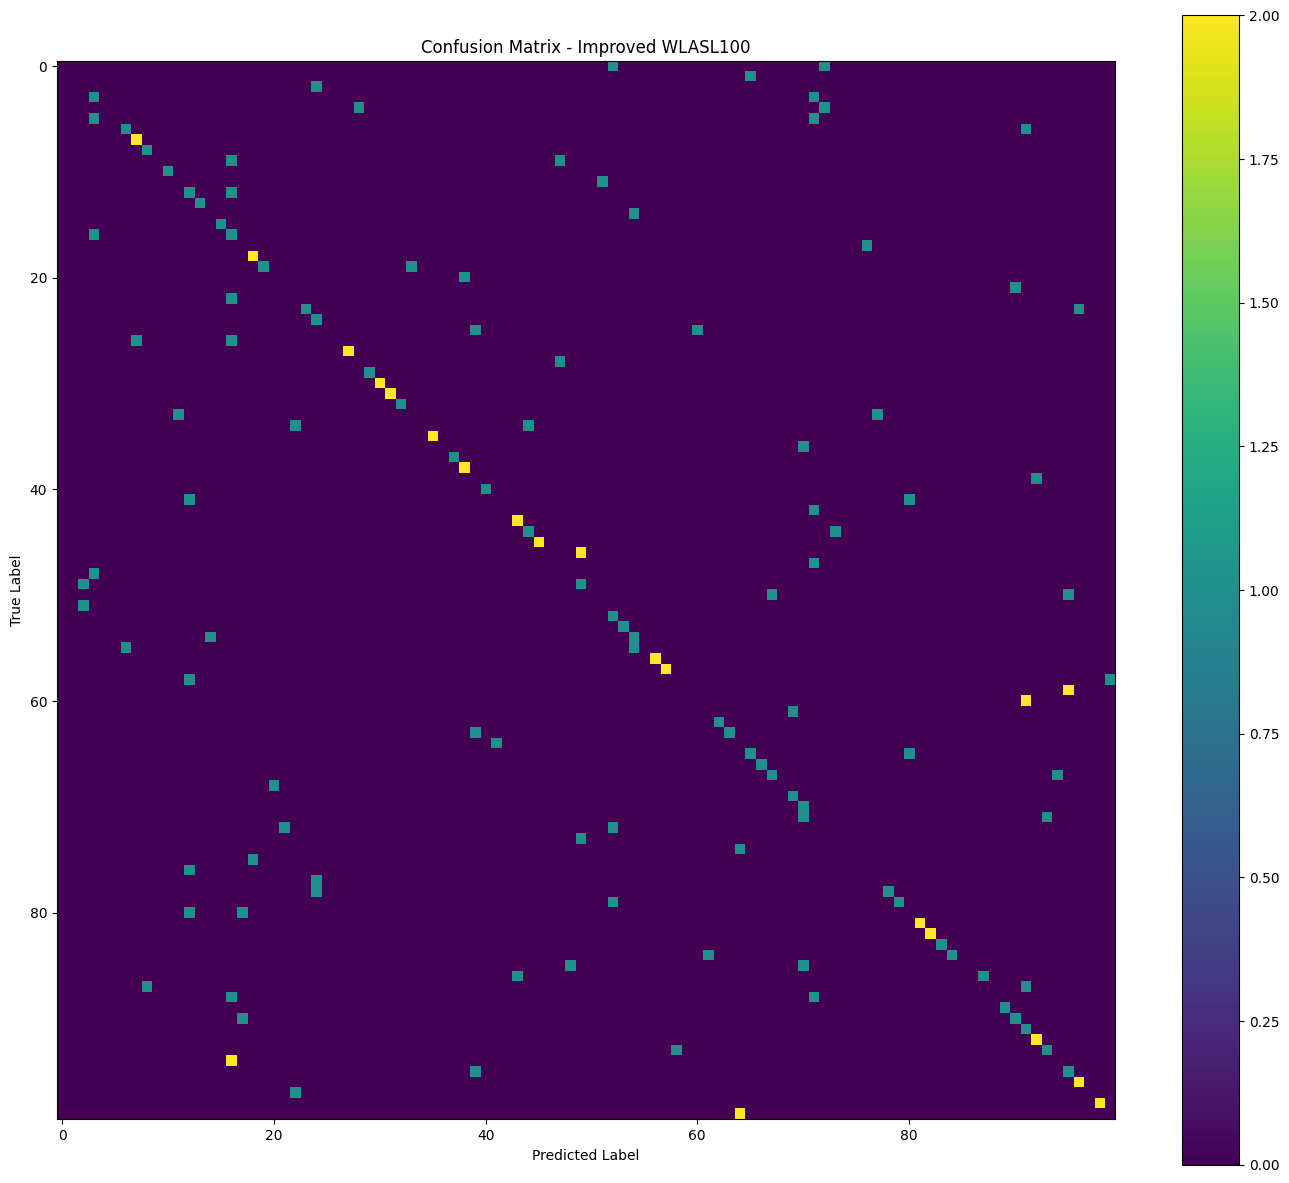

In [19]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(14, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Improved WLASL100")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.tight_layout()
plt.show()

In [20]:
confusion_records = []

for true_label in range(NUM_CLASSES):
    for pred_label in range(NUM_CLASSES):
        count = cm[true_label, pred_label]

        if true_label != pred_label and count > 0:
            confusion_records.append({
                "true_label_id": true_label,
                "true_gloss": id_to_gloss.get(true_label, str(true_label)),
                "predicted_label_id": pred_label,
                "predicted_gloss": id_to_gloss.get(pred_label, str(pred_label)),
                "count": int(count)
            })

confusion_df = pd.DataFrame(confusion_records)

if len(confusion_df) > 0:
    confusion_df = confusion_df.sort_values("count", ascending=False)

CONFUSION_FILE = EVAL_DIR / "improved_wlasl100_common_confusions.csv"
confusion_df.to_csv(CONFUSION_FILE, index=False)

print("Saved common confusions to:")
print(CONFUSION_FILE)

confusion_df.head(20)

Saved common confusions to:
E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_common_confusions.csv


,true_label_id,true_gloss,predicted_label_id,predicted_gloss,count
81,94,who,16,candy,2
84,99,yes,64,need,2
37,46,graduate,49,help,2
49,59,man,95,woman,2
50,60,many,91,want,2
5,4,basketball,28,cow,1
6,4,basketball,72,play,1
7,5,bed,3,apple,1
8,5,bed,71,pizza,1
9,6,before,91,want,1


## 11. Prediction-level analysis

This creates a detailed table for every test prediction, including confidence and Top-5 predictions.

In [21]:
prediction_records = []
test_df_reset = test_df.reset_index(drop=True)

for i in range(len(y_true)):
    true_id = int(y_true[i])
    pred_id = int(y_pred[i])
    confidence = float(y_probs[i][pred_id])

    top5_ids = np.argsort(y_probs[i])[-5:][::-1]
    top5_probs = y_probs[i][top5_ids]

    top5_glosses = [
        id_to_gloss.get(int(label_id), str(label_id))
        for label_id in top5_ids
    ]

    top5_contains_true = true_id in top5_ids

    prediction_records.append({
        "video_id": test_df_reset.iloc[i]["video_id"],
        "true_label_id": true_id,
        "true_gloss": id_to_gloss.get(true_id, str(true_id)),
        "predicted_label_id": pred_id,
        "predicted_gloss": id_to_gloss.get(pred_id, str(pred_id)),
        "confidence": confidence,
        "correct_top1": true_id == pred_id,
        "correct_top5": top5_contains_true,
        "top5_label_ids": ", ".join([str(int(x)) for x in top5_ids]),
        "top5_glosses": ", ".join(top5_glosses),
        "top5_probabilities": ", ".join([f"{float(p):.4f}" for p in top5_probs]),
        "keypoint_path": test_df_reset.iloc[i]["keypoint_path"],
        "video_path": test_df_reset.iloc[i]["video_path"]
    })

predictions_df = pd.DataFrame(prediction_records)

PREDICTIONS_FILE = EVAL_DIR / "improved_wlasl100_test_predictions.csv"
predictions_df.to_csv(PREDICTIONS_FILE, index=False)

print("Saved prediction-level results to:")
print(PREDICTIONS_FILE)

predictions_df.head()

Saved prediction-level results to:
E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_test_predictions.csv


,video_id,true_label_id,true_gloss,predicted_label_id,predicted_gloss,confidence,correct_top1,correct_top5,top5_label_ids,top5_glosses,top5_probabilities,keypoint_path,video_path
0,56557,83,table,83,table,0.301143,True,True,"83, 77, 5, 43, 50","table, school, bed, full, hot","0.3011, 0.0949, 0.0708, 0.0486, 0.0429",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\56557.mp4
1,69290,30,dark,30,dark,0.928496,True,True,"30, 86, 28, 18, 25","dark, thanksgiving, cow, change, cool","0.9285, 0.0056, 0.0054, 0.0050, 0.0049",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\69290.mp4
2,57639,86,thanksgiving,87,thin,0.286319,False,True,"87, 86, 93, 8, 25","thin, thanksgiving, white, birthday, cool","0.2863, 0.2685, 0.1177, 0.0415, 0.0269",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\57639.mp4
3,64280,99,yes,64,need,0.520233,False,False,"64, 55, 34, 26, 44","need, last, dog, corn, give","0.5202, 0.0539, 0.0456, 0.0363, 0.0275",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\64280.mp4
4,33273,58,like,12,bowling,0.302262,False,True,"12, 99, 58, 50, 76","bowling, yes, like, hot, same","0.3023, 0.1131, 0.0737, 0.0481, 0.0369",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\33273.mp4


In [22]:
print("Correct Top-1 prediction examples:")
predictions_df[predictions_df["correct_top1"] == True].sort_values(
    "confidence",
    ascending=False
).head(10)

Correct Top-1 prediction examples:


,video_id,true_label_id,true_gloss,predicted_label_id,predicted_gloss,confidence,correct_top1,correct_top5,top5_label_ids,top5_glosses,top5_probabilities,keypoint_path,video_path
63,53275,81,son,81,son,0.948184,True,True,"81, 96, 83, 27, 8","son, work, table, cousin, birthday","0.9482, 0.0076, 0.0044, 0.0042, 0.0034",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\53275.mp4
1,69290,30,dark,30,dark,0.928496,True,True,"30, 86, 28, 18, 25","dark, thanksgiving, cow, change, cool","0.9285, 0.0056, 0.0054, 0.0050, 0.0049",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\69290.mp4
76,8942,15,can,15,can,0.899785,True,True,"15, 72, 66, 45, 57","can, play, now, go, letter","0.8998, 0.0331, 0.0243, 0.0047, 0.0030",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\08942.mp4
148,32338,56,later,56,later,0.897774,True,True,"56, 84, 87, 20, 45","later, tall, thin, city, go","0.8978, 0.0160, 0.0091, 0.0055, 0.0041",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\32338.mp4
36,66816,98,year,98,year,0.894669,True,True,"98, 88, 11, 96, 89","year, thursday, book, work, time","0.8947, 0.0132, 0.0120, 0.0083, 0.0061",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\66816.mp4
88,40130,67,orange,67,orange,0.889389,True,True,"67, 94, 7, 26, 97","orange, who, bird, corn, wrong","0.8894, 0.0400, 0.0221, 0.0102, 0.0070",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\40130.mp4
45,69364,49,help,49,help,0.863319,True,True,"49, 46, 24, 29, 6","help, graduate, cook, dance, before","0.8633, 0.0727, 0.0137, 0.0059, 0.0057",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\69364.mp4
19,23775,43,full,43,full,0.854463,True,True,"43, 25, 35, 87, 26","full, cool, drink, thin, corn","0.8545, 0.0364, 0.0119, 0.0109, 0.0056",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\23775.mp4
110,62251,91,want,91,want,0.824190,True,True,"91, 66, 61, 51, 60","want, now, medicine, how, many","0.8242, 0.0203, 0.0181, 0.0173, 0.0141",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\62251.mp4
34,55368,82,study,82,study,0.810429,True,True,"82, 29, 77, 43, 90","study, dance, school, full, walk","0.8104, 0.0304, 0.0211, 0.0131, 0.0102",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\55368.mp4


In [23]:
print("Top-1 wrong but Top-5 correct examples:")
predictions_df[
    (predictions_df["correct_top1"] == False) &
    (predictions_df["correct_top5"] == True)
].sort_values("confidence", ascending=False).head(10)

Top-1 wrong but Top-5 correct examples:


,video_id,true_label_id,true_gloss,predicted_label_id,predicted_gloss,confidence,correct_top1,correct_top5,top5_label_ids,top5_glosses,top5_probabilities,keypoint_path,video_path
35,32261,55,last,6,before,0.941213,False,True,"6, 55, 16, 45, 84","before, last, candy, go, tall","0.9412, 0.0065, 0.0050, 0.0030, 0.0028",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\32261.mp4
124,57283,85,tell,48,hearing,0.910105,False,True,"48, 16, 85, 3, 25","hearing, candy, tell, apple, cool","0.9101, 0.0329, 0.0088, 0.0073, 0.0032",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\57283.mp4
39,49598,77,school,24,cook,0.877694,False,True,"24, 77, 49, 22, 11","cook, school, help, color, book","0.8777, 0.0178, 0.0124, 0.0116, 0.0090",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\49598.mp4
91,22114,41,fish,12,bowling,0.822035,False,True,"12, 80, 41, 64, 75","bowling, short, fish, need, right","0.8220, 0.0494, 0.0187, 0.0170, 0.0101",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\22114.mp4
156,34742,59,man,95,woman,0.708290,False,True,"95, 39, 61, 59, 43","woman, fine, medicine, man, full","0.7083, 0.1975, 0.0103, 0.0097, 0.0062",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\34742.mp4
43,63669,95,woman,39,fine,0.697811,False,True,"39, 95, 25, 43, 61","fine, woman, cool, full, medicine","0.6978, 0.1083, 0.0625, 0.0185, 0.0148",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\63669.mp4
75,8916,16,candy,3,apple,0.634575,False,True,"3, 9, 27, 84, 16","apple, black, cousin, tall, candy","0.6346, 0.0529, 0.0415, 0.0291, 0.0250",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\08916.mp4
123,5230,4,basketball,28,cow,0.631662,False,True,"28, 4, 30, 40, 32","cow, basketball, dark, finish, decide","0.6317, 0.1657, 0.0606, 0.0156, 0.0128",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\05230.mp4
153,25330,46,graduate,49,help,0.617628,False,True,"49, 46, 24, 18, 29","help, graduate, cook, change, dance","0.6176, 0.1996, 0.0722, 0.0244, 0.0079",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\25330.mp4
82,57278,85,tell,70,pink,0.573607,False,True,"70, 85, 94, 16, 87","pink, tell, who, candy, thin","0.5736, 0.1073, 0.0713, 0.0421, 0.0227",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\57278.mp4


In [24]:
print("High-confidence wrong predictions:")
predictions_df[
    predictions_df["correct_top1"] == False
].sort_values("confidence", ascending=False).head(15)

High-confidence wrong predictions:


,video_id,true_label_id,true_gloss,predicted_label_id,predicted_gloss,confidence,correct_top1,correct_top5,top5_label_ids,top5_glosses,top5_probabilities,keypoint_path,video_path
35,32261,55,last,6,before,0.941213,False,True,"6, 55, 16, 45, 84","before, last, candy, go, tall","0.9412, 0.0065, 0.0050, 0.0030, 0.0028",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\32261.mp4
124,57283,85,tell,48,hearing,0.910105,False,True,"48, 16, 85, 3, 25","hearing, candy, tell, apple, cool","0.9101, 0.0329, 0.0088, 0.0073, 0.0032",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\57283.mp4
39,49598,77,school,24,cook,0.877694,False,True,"24, 77, 49, 22, 11","cook, school, help, color, book","0.8777, 0.0178, 0.0124, 0.0116, 0.0090",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\49598.mp4
91,22114,41,fish,12,bowling,0.822035,False,True,"12, 80, 41, 64, 75","bowling, short, fish, need, right","0.8220, 0.0494, 0.0187, 0.0170, 0.0101",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\22114.mp4
127,51059,79,shirt,52,jacket,0.788287,False,False,"52, 0, 55, 81, 78","jacket, accident, last, son, secretary","0.7883, 0.0376, 0.0326, 0.0140, 0.0139",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\51059.mp4
122,58361,88,thursday,71,pizza,0.783308,False,False,"71, 3, 6, 70, 16","pizza, apple, before, pink, candy","0.7833, 0.0338, 0.0229, 0.0214, 0.0183",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\58361.mp4
156,34742,59,man,95,woman,0.708290,False,True,"95, 39, 61, 59, 43","woman, fine, medicine, man, full","0.7083, 0.1975, 0.0103, 0.0097, 0.0062",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\34742.mp4
43,63669,95,woman,39,fine,0.697811,False,True,"39, 95, 25, 43, 61","fine, woman, cool, full, medicine","0.6978, 0.1083, 0.0625, 0.0185, 0.0148",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\63669.mp4
23,65163,5,bed,3,apple,0.654495,False,False,"3, 47, 9, 28, 27","apple, hat, black, cow, cousin","0.6545, 0.0878, 0.0204, 0.0187, 0.0179",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\65163.mp4
75,8916,16,candy,3,apple,0.634575,False,True,"3, 9, 27, 84, 16","apple, black, cousin, tall, candy","0.6346, 0.0529, 0.0415, 0.0291, 0.0250",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\08916.mp4


In [25]:
print("Low-confidence predictions:")
predictions_df.sort_values("confidence", ascending=True).head(15)

Low-confidence predictions:


,video_id,true_label_id,true_gloss,predicted_label_id,predicted_gloss,confidence,correct_top1,correct_top5,top5_label_ids,top5_glosses,top5_probabilities,keypoint_path,video_path
42,28116,50,hot,67,orange,0.115330,False,True,"67, 95, 40, 50, 94","orange, woman, finish, hot, who","0.1153, 0.0830, 0.0548, 0.0540, 0.0525",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\28116.mp4
47,57632,86,thanksgiving,43,full,0.129388,False,True,"43, 86, 87, 67, 95","full, thanksgiving, thin, orange, woman","0.1294, 0.1249, 0.1079, 0.0959, 0.0814",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\57632.mp4
10,65242,12,bowling,16,candy,0.136765,False,True,"16, 12, 75, 3, 88","candy, bowling, right, apple, thursday","0.1368, 0.1293, 0.1041, 0.0946, 0.0774",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\65242.mp4
146,36946,63,mother,39,fine,0.142337,False,True,"39, 40, 95, 10, 63","fine, finish, woman, blue, mother","0.1423, 0.1181, 0.1101, 0.0637, 0.0541",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\36946.mp4
13,24941,45,go,45,go,0.142599,True,True,"45, 30, 23, 86, 78","go, dark, computer, thanksgiving, secretary","0.1426, 0.0876, 0.0732, 0.0607, 0.0511",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\24941.mp4
111,62988,92,what,92,what,0.155655,True,True,"92, 55, 88, 19, 21","what, last, thursday, cheat, clothes","0.1557, 0.1059, 0.0472, 0.0426, 0.0390",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\62988.mp4
128,22130,41,fish,80,short,0.164729,False,True,"80, 12, 41, 88, 79","short, bowling, fish, thursday, shirt","0.1647, 0.1139, 0.1050, 0.1025, 0.0639",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\22130.mp4
95,65084,3,apple,71,pizza,0.167787,False,True,"71, 34, 16, 3, 7","pizza, dog, candy, apple, bird","0.1678, 0.1437, 0.1363, 0.0917, 0.0346",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\65084.mp4
40,65328,17,chair,76,same,0.168383,False,True,"76, 57, 17, 98, 75","same, letter, chair, year, right","0.1684, 0.1578, 0.0995, 0.0960, 0.0430",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\65328.mp4
81,64091,97,wrong,22,color,0.172055,False,False,"22, 85, 0, 6, 48","color, tell, accident, before, hearing","0.1721, 0.1447, 0.0656, 0.0639, 0.0593",E:\Be_My_Ear\data\processed\ASL\WLASL100\keypo...,E:\Be_My_Ear\data\raw\ASL\videos\64091.mp4


## 12. Confidence analysis

This helps decide what confidence threshold might be useful later when we build the actual app.

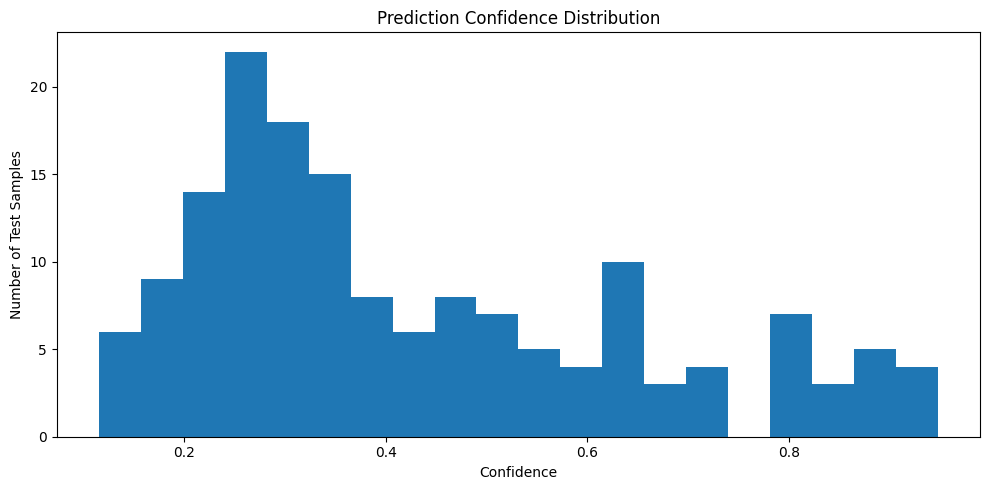

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(predictions_df["confidence"], bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Test Samples")
plt.tight_layout()
plt.show()

In [27]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_records = []

for threshold in thresholds:
    confident_df = predictions_df[predictions_df["confidence"] >= threshold]

    if len(confident_df) == 0:
        coverage = 0
        top1_at_threshold = np.nan
        top5_at_threshold = np.nan
    else:
        coverage = len(confident_df) / len(predictions_df)
        top1_at_threshold = confident_df["correct_top1"].mean()
        top5_at_threshold = confident_df["correct_top5"].mean()

    threshold_records.append({
        "confidence_threshold": threshold,
        "coverage": coverage,
        "top1_accuracy_on_confident_samples": top1_at_threshold,
        "top5_accuracy_on_confident_samples": top5_at_threshold,
        "num_confident_samples": len(confident_df)
    })

threshold_df = pd.DataFrame(threshold_records)

THRESHOLD_FILE = EVAL_DIR / "improved_wlasl100_confidence_threshold_analysis.csv"
threshold_df.to_csv(THRESHOLD_FILE, index=False)

print("Saved confidence threshold analysis to:")
print(THRESHOLD_FILE)

threshold_df

Saved confidence threshold analysis to:
E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_confidence_threshold_analysis.csv


,confidence_threshold,coverage,top1_accuracy_on_confident_samples,top5_accuracy_on_confident_samples,num_confident_samples
0,0.2,0.905063,0.454545,0.790210,143
1,0.3,0.620253,0.520408,0.816327,98
2,0.4,0.449367,0.577465,0.845070,71
3,0.5,0.310127,0.673469,0.897959,49
4,0.6,0.234177,0.675676,0.918919,37
5,0.7,0.145570,0.695652,0.913043,23
6,0.8,0.101266,0.750000,1.000000,16
7,0.9,0.025316,0.500000,1.000000,4


## 13. Final evaluation summary

In [28]:
print("Final evaluation summary")
print("------------------------")
print(f"Dataset: WLASL100")
print(f"Clean samples: {len(df)}")
print(f"Test samples: {len(test_df)}")
print(f"Classes: {NUM_CLASSES}")
print(f"Model: BiGRU + Temporal Attention")
print(f"Input shape: (60, {INPUT_SIZE})")
print(f"Test Top-1 Accuracy: {test_top1:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Top-5 Accuracy: {test_top5:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print()
print("Saved report files:")
print("-", OVERALL_METRICS_FILE)
print("-", PER_CLASS_FILE)
print("-", CONFUSION_FILE)
print("-", PREDICTIONS_FILE)
print("-", THRESHOLD_FILE)

Final evaluation summary
------------------------
Dataset: WLASL100
Clean samples: 1013
Test samples: 158
Classes: 100
Model: BiGRU + Temporal Attention
Input shape: (60, 516)
Test Top-1 Accuracy: 0.4304
Test Top-3 Accuracy: 0.7089
Test Top-5 Accuracy: 0.7911
Test Macro F1: 0.3855

Saved report files:
- E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_overall_metrics.csv
- E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_per_class_performance.csv
- E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_common_confusions.csv
- E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_test_predictions.csv
- E:\Be_My_Ear\reports\phase1_wlasl100\improved_wlasl100_confidence_threshold_analysis.csv
